# Sci/Tech News Q&A with Gemma (RAG) + Visual Analytics
**Track:** Build w Gemma — Gemma Challenge (Google Developer Group) · Hack Fiesta Miami, Aug 2026

This notebook implements a retrieval-augmented generation (RAG) pipeline on the **20 Newsgroups** dataset (`SetFit/20_newsgroups`), plus a scikit-learn analysis layer and five designed charts:

1. Load 20 Newsgroups from Hugging Face and keep only the **Sci/Tech** groups (`sci.*` and `comp.*`, 9 subtopics).
2. Clean, chunk and embed the posts with a small sentence-embedding model (metadata is kept per chunk).
3. Build a **FAISS** similarity index, with optional metadata filters (subtopic / group).
4. Use **scikit-learn** to measure how well the embedding space separates the subtopics (KMeans, Logistic Regression, PCA).
5. Draw a **Marimekko**, **dendrogram**, **stream graph**, **radial bar charts** and a **3D PCA volume plot** in one high-contrast palette with extruded (3D-look) shapes.
6. Feed retrieved context to Gemma (`google/gemma-2-2b-it`) and generate a cited answer.
7. Export the curated corpus, embeddings and FAISS index.

## 1. Install dependencies

In [1]:
!pip install -qq --only-binary=:all: transformers accelerate datasets sentence-transformers faiss-cpu bitsandbytes
!pip install -qq --only-binary=:all: pandas==2.2.2 matplotlib==3.8.4 scikit-learn==1.3.2 scipy==1.11.4 numpy==1.26.4

print("Environment dependencies normalized.")

ERROR: Ignored the following yanked versions: 3.0.4
ERROR: Could not find a version that satisfies the requirement pandas==2.2.2 (from versions: 2.2.3, 2.3.0, 2.3.1, 2.3.2, 2.3.3, 3.0.0rc0, 3.0.0rc1, 3.0.0rc2, 3.0.0, 3.0.1, 3.0.2, 3.0.3, 3.0.5, 3.0.6)
ERROR: No matching distribution found for pandas==2.2.2
Environment dependencies normalized.


## 2. Configuration

In [2]:
import re, json
import numpy as np
import pandas as pd
from datasets import load_dataset

SEED = 42
KEEP_PREFIXES = ("sci.", "comp.")
MAX_TRAIN_PER_TOPIC = 300
MAX_TEST_PER_TOPIC = 100
MIN_WORDS = 30
CHUNK_WORDS, CHUNK_OVERLAP, MAX_CHUNKS_PER_DOC = 120, 20, 4
EMBED_MODEL = "all-MiniLM-L6-v2"
GEMMA_MODEL_ID = "google/gemma-2-2b-it"

ds = load_dataset("SetFit/20_newsgroups")
print(ds)

NEWSGROUPS = ["comp.graphics", "comp.sys.ibm.pc.hardware",
              "comp.sys.mac.hardware", "comp.windows.x", "misc.forsale", "sci.crypt", "sci.electronics", "sci.med",
              "sci.space"]

def to_df(split):
    df = split.to_pandas()
    if "label_text" not in df.columns:
        df["label_text"] = df["label"].map(lambda i: NEWSGROUPS[i])
    return df

raw_train, raw_test = to_df(ds["train"]), to_df(ds["test"])
print("Raw rows:", len(raw_train), "train /", len(raw_test), "test")
print(raw_train.label_text.value_counts().head(20))

Repo card metadata block was not found. Setting CardData to empty.


DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'label_text'],
        num_rows: 11314
    })
    test: Dataset({
        features: ['text', 'label', 'label_text'],
        num_rows: 7532
    })
})
Raw rows: 11314 train / 7532 test
label_text
rec.sport.hockey            600
soc.religion.christian      599
rec.motorcycles             598
rec.sport.baseball          597
sci.crypt                   595
sci.med                     594
rec.autos                   594
sci.space                   593
comp.windows.x              593
comp.os.ms-windows.misc     591
sci.electronics             591
comp.sys.ibm.pc.hardware    590
misc.forsale                585
comp.graphics               584
comp.sys.mac.hardware       578
talk.politics.mideast       564
talk.politics.guns          546
alt.atheism                 480
talk.politics.misc          465
talk.religion.misc          377
Name: count, dtype: int64


In [4]:
EMAIL = re.compile(r"\S+@\S+")

def make_title(raw):
    for line in raw.splitlines():
        s = line.strip()
        if (len(s) >= 15 and not s.startswith((">", "|", "-", "=", ":"))
                and "@" not in s and "writes:" not in s and not s.lower().startswith("in article")):
            return s[:90]
    return re.sub(r"\s+", " ", raw).strip()[:90]

def clean(text):
    t = re.sub(r"(?m)^\s*>.*$", " ", text)
    t = EMAIL.sub(" ", t)
    t = re.sub(r"[-=_*~#]{4,}", " ", t)
    return re.sub(r"\s+", " ", t).strip()

def prepare(df, prefix, per_topic):
    df = df[df.label_text.str.startswith(KEEP_PREFIXES)].copy()
    df["title"] = [make_title(t) for t in df.text]
    df["clean"] = df.text.map(clean)
    df["n_words"] = df.clean.str.split().str.len()
    df = df[df.n_words >= MIN_WORDS]
    df = df.sample(frac=1, random_state=SEED).groupby("label_text", group_keys=False).head(per_topic)
    df["group"] = df.label_text.str.split(".").str[0]
    df = df.sort_values("label_text").reset_index(drop=True)
    df["doc_id"] = [f"{prefix}-{i}" for i in range(len(df))]
    return df[["doc_id", "label_text", "group", "title", "n_words", "clean"]]

train_df = prepare(raw_train, "train", MAX_TRAIN_PER_TOPIC)
test_df = prepare(raw_test, "test", MAX_TEST_PER_TOPIC)

# sci.* first, then comp.*
TOPICS = sorted(train_df.label_text.unique(), key=lambda t: (t.split(".")[0] != "sci", t))
print(f"{len(train_df)} train docs, {len(test_df)} test docs, {len(TOPICS)} subtopics: {TOPICS}\n")
print(train_df.groupby(["group", "label_text"]).n_words.agg(["count", "median", "max"]))
train_df.head(3)

2700 train docs, 900 test docs, 9 subtopics: ['sci.crypt', 'sci.electronics', 'sci.med', 'sci.space', 'comp.graphics', 'comp.os.ms-windows.misc', 'comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware', 'comp.windows.x']

                                count  median   max
group label_text                                   
comp  comp.graphics               300    74.0  9103
      comp.os.ms-windows.misc     300    89.0  2362
      comp.sys.ibm.pc.hardware    300    96.0  1727
      comp.sys.mac.hardware       300    83.0   709
      comp.windows.x              300    95.5  7523
sci   sci.crypt                   300   145.5  5475
      sci.electronics             300   103.5   657
      sci.med                     300   113.0  4965
      sci.space                   300    94.5  6100


,doc_id,label_text,group,title,n_words,clean
0,train-0,comp.graphics,comp,"Well, i have a 386/40 with SVGA 1Mb. (OAK chip...",36,"Hi there!... Well, i have a 386/40 with SVGA 1..."
1,train-1,comp.graphics,comp,I am looking for a public domain 3d viewer. I...,37,I am looking for a public domain 3d viewer. It...
2,train-2,comp.graphics,comp,I'm not sure if this is the correct place to a...,66,I'm not sure if this is the correct place to a...


## 3. Chunk

In [5]:
from sentence_transformers import SentenceTransformer

def chunk_words(text, size=CHUNK_WORDS, overlap=CHUNK_OVERLAP, max_chunks=MAX_CHUNKS_PER_DOC):
    words, step, out = text.split(), size - overlap, []
    for start in range(0, max(len(words), 1), step):
        piece = words[start:start + size]
        if len(piece) < 20 and out:
            break
        out.append(" ".join(piece))
        if len(out) >= max_chunks or start + size >= len(words):
            break
    return out

rows = []
for r in train_df.itertuples():
    for j, ch in enumerate(chunk_words(r.clean)):
        rows.append(dict(chunk_id=f"{r.doc_id}#{j}", doc_id=r.doc_id, chunk_no=j, title=r.title,
                         label_text=r.label_text, group=r.group, n_words=len(ch.split()), text=ch))
chunks_df = pd.DataFrame(rows)

embedder = SentenceTransformer(EMBED_MODEL)
embeddings = embedder.encode(chunks_df.text.tolist(), batch_size=128,
                             show_progress_bar=True, normalize_embeddings=True).astype("float32")
print("Chunks:", len(chunks_df), "| embedding matrix:", embeddings.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/35 [00:00<?, ?it/s]

Chunks: 4476 | embedding matrix: (4476, 384)


## 4. FAISS index

In [6]:
import faiss

dim = embeddings.shape[1]
index = faiss.IndexFlatIP(dim)
index.add(embeddings)
print(f"FAISS index built with {index.ntotal} vectors of dimension {dim}.")

def retrieve(question, top_k=5, topic=None, group=None):
    """Top-k chunks; optionally restrict to one subtopic (e.g. 'sci.med') or group ('sci' / 'comp')."""
    q = embedder.encode([question], normalize_embeddings=True).astype("float32")
    fetch_k = index.ntotal if (topic or group) else top_k
    scores, idxs = index.search(q, fetch_k)
    hits = []
    for s, i in zip(scores[0], idxs[0]):
        row = chunks_df.iloc[i]
        if topic and row.label_text != topic: continue
        if group and row.group != group: continue
        hits.append(dict(title=row.title, text=row.text, topic=row.label_text, score=float(s)))
        if len(hits) == top_k: break
    return hits

for r in retrieve("orbital launch of a satellite", top_k=3):
    print(f"{r['score']:.3f}  [{r['topic']}]  {r['title']}")
print("--- filtered to sci.med ---")
for r in retrieve("treatment for headaches", top_k=3, topic="sci.med"):
    print(f"{r['score']:.3f}  [{r['topic']}]  {r['title']}")

FAISS index built with 4476 vectors of dimension 384.
0.435  [sci.space]  I would just like to point out that it is much easier to place an
0.412  [sci.space]  Ethnocentric USian that I am, I've assumed that we and the
0.405  [sci.space]  I should probably re-post this with another title, so that
--- filtered to sci.med ---
0.578  [sci.med]  Two approaches that I've used: Tofranil, 50 mg qhs, Naproxen 250mg bid.
0.547  [sci.med]  As promised, below is a personal critique of a Pressure Point Massager
0.520  [sci.med]  You certainly do not see OTC preparations advertised as such.


## 5. Scikit-learn analysis

In [7]:
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.metrics import (classification_report, f1_score, adjusted_rand_score,
                             normalized_mutual_info_score, silhouette_score)

# document-level train chunk embeddings
uniq, inv = np.unique(chunks_df.doc_id.values, return_inverse=True)
doc_emb = np.zeros((len(uniq), dim), dtype="float32")
np.add.at(doc_emb, inv, embeddings)
doc_emb /= np.linalg.norm(doc_emb, axis=1, keepdims=True)
doc_meta = train_df.set_index("doc_id").loc[uniq]
y_train = doc_meta.label_text.values

# test queries
test_df["query_text"] = test_df.clean.map(lambda t: " ".join(t.split()[:200]))
Xte = embedder.encode(test_df.query_text.tolist(), batch_size=128, normalize_embeddings=True).astype("float32")
y_test = test_df.label_text.values

# FAISS retrieval precision@5
K_EVAL = 5
_, I = index.search(Xte, K_EVAL)
hit = chunks_df.label_text.values[I] == y_test[:, None]
prec_by_topic = pd.Series(hit.mean(1)).groupby(y_test).mean().reindex(TOPICS)
print(f"Retrieval precision@{K_EVAL}: {hit.mean():.3f} overall")
print(prec_by_topic.round(3).to_string(), "\n")

# supervised classifier
clf = LogisticRegression(max_iter=3000, C=4.0).fit(doc_emb, y_train)
pred = clf.predict(Xte)
f1_by_topic = pd.Series(f1_score(y_test, pred, labels=TOPICS, average=None), index=TOPICS)
print(classification_report(y_test, pred, labels=TOPICS, digits=3))

# unsupervised clustering
km = KMeans(n_clusters=len(TOPICS), n_init=10, random_state=SEED).fit(doc_emb)
print(f"KMeans  ARI={adjusted_rand_score(y_train, km.labels_):.3f}  "
      f"NMI={normalized_mutual_info_score(y_train, km.labels_):.3f}  "
      f"silhouette={silhouette_score(doc_emb, km.labels_, metric='cosine', sample_size=min(2000, len(doc_emb)), random_state=SEED):.3f}")
pd.crosstab(y_train, km.labels_).rename_axis(index="true subtopic", columns="KMeans cluster")

Retrieval precision@5: 0.670 overall
sci.crypt                   0.928
sci.electronics             0.470
sci.med                     0.894
sci.space                   0.732
comp.graphics               0.566
comp.os.ms-windows.misc     0.540
comp.sys.ibm.pc.hardware    0.626
comp.sys.mac.hardware       0.524
comp.windows.x              0.754 

                          precision    recall  f1-score   support

               sci.crypt      0.830     0.930     0.877       100
         sci.electronics      0.671     0.570     0.616       100
                 sci.med      0.880     0.950     0.913       100
               sci.space      0.888     0.790     0.836       100
           comp.graphics      0.643     0.720     0.679       100
 comp.os.ms-windows.misc      0.660     0.620     0.639       100
comp.sys.ibm.pc.hardware      0.615     0.670     0.641       100
   comp.sys.mac.hardware      0.774     0.720     0.746       100
          comp.windows.x      0.806     0.790     0.798     

KMeans cluster,0,1,2,3,4,5,6,7,8
true subtopic,,,,,,,,,
comp.graphics,21,1,13,8,0,7,180,38,32
comp.os.ms-windows.misc,35,0,2,97,0,16,89,48,13
comp.sys.ibm.pc.hardware,77,0,1,87,0,3,3,120,9
comp.sys.mac.hardware,99,0,0,76,0,1,10,96,18
comp.windows.x,7,0,6,6,0,207,55,10,9
sci.crypt,4,233,2,1,1,1,9,8,41
sci.electronics,93,4,3,6,0,0,10,29,155
sci.med,4,0,8,1,251,0,1,0,35
sci.space,5,0,228,0,0,0,5,2,60


## 6. Analytics

In [8]:
import os
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib import patheffects as pe
from matplotlib.patches import Rectangle, Polygon, Patch
from matplotlib.lines import Line2D
from cycler import cycler

os.makedirs("figures", exist_ok=True)

BG, PANEL, FG, MUTED, GRID = "#0B1020", "#121A33", "#EEF2FF", "#94A3C4", "#2A3558"
PALETTE = {
    "sci.crypt": "#FF4D6D", "sci.electronics": "#FFB000", "sci.med": "#2DD4BF", "sci.space": "#38BDF8",
    "comp.graphics": "#C084FC", "comp.os.ms-windows.misc": "#A3E635", "comp.sys.ibm.pc.hardware": "#F472B6",
    "comp.sys.mac.hardware": "#CBD5E1", "comp.windows.x": "#818CF8",
}
_fallback = ["#F59E0B", "#10B981", "#3B82F6", "#EF4444", "#8B5CF6", "#EC4899", "#14B8A6", "#F97316", "#84CC16"]
PAL = {t: PALETTE.get(t, _fallback[i % len(_fallback)]) for i, t in enumerate(TOPICS)}

SHORT = {"comp.os.ms-windows.misc": "comp·windows", "comp.sys.ibm.pc.hardware": "comp·pc-hw",
         "comp.sys.mac.hardware": "comp·mac-hw", "comp.windows.x": "comp·x-windows"}
def short(t):
    return SHORT.get(t, t.replace(".", "·", 1))

mpl.rcParams.update({
    "figure.facecolor": BG, "axes.facecolor": BG, "savefig.facecolor": BG,
    "text.color": FG, "axes.labelcolor": FG, "axes.edgecolor": GRID,
    "xtick.color": MUTED, "ytick.color": MUTED, "grid.color": GRID,
    "font.size": 11, "axes.titleweight": "bold", "axes.titlesize": 15,
    "axes.prop_cycle": cycler(color=[PAL[t] for t in TOPICS]),
})

def shade(color, f):
    """f < 1 darkens, f > 1 lightens (mix towards white)."""
    r, g, b = mcolors.to_rgb(color)
    if f <= 1:
        return (r * f, g * f, b * f)
    k = min(f - 1, 1)
    return (r + (1 - r) * k, g + (1 - g) * k, b + (1 - b) * k)

def on_color(color):
    r, g, b = mcolors.to_rgb(color)
    return BG if (0.299 * r + 0.587 * g + 0.114 * b) > 0.55 else "#FFFFFF"

def extruded_cell(ax, x0, y0, w0, h0, color, depth=0.012, gap=0.004, z=2):
    """Rectangle with a right face and a top face -> looks like a 3D slab. Returns centre of the front face."""
    dx, dy = min(depth, w0 * 0.25), min(depth * 1.6, h0 * 0.35)
    w, h = w0 - dx - gap, h0 - dy - gap
    if w <= 0 or h <= 0:
        return None
    ax.add_patch(Polygon([(x0 + w, y0), (x0 + w + dx, y0 + dy), (x0 + w + dx, y0 + h + dy), (x0 + w, y0 + h)],
                         closed=True, fc=shade(color, 0.55), ec=BG, lw=0.5, zorder=z + 1))
    ax.add_patch(Polygon([(x0, y0 + h), (x0 + dx, y0 + h + dy), (x0 + w + dx, y0 + h + dy), (x0 + w, y0 + h)],
                         closed=True, fc=shade(color, 1.35), ec=BG, lw=0.5, zorder=z + 1))
    ax.add_patch(Rectangle((x0, y0), w, h, fc=color, ec=BG, lw=0.7, zorder=z + 2))
    return x0 + w / 2, y0 + h / 2

def save_fig(fig, name):
    fig.savefig(f"figures/{name}.png", dpi=200, bbox_inches="tight", facecolor=fig.get_facecolor())
    print("saved figures/%s.png" % name)

saved figures/1_marimekko.png


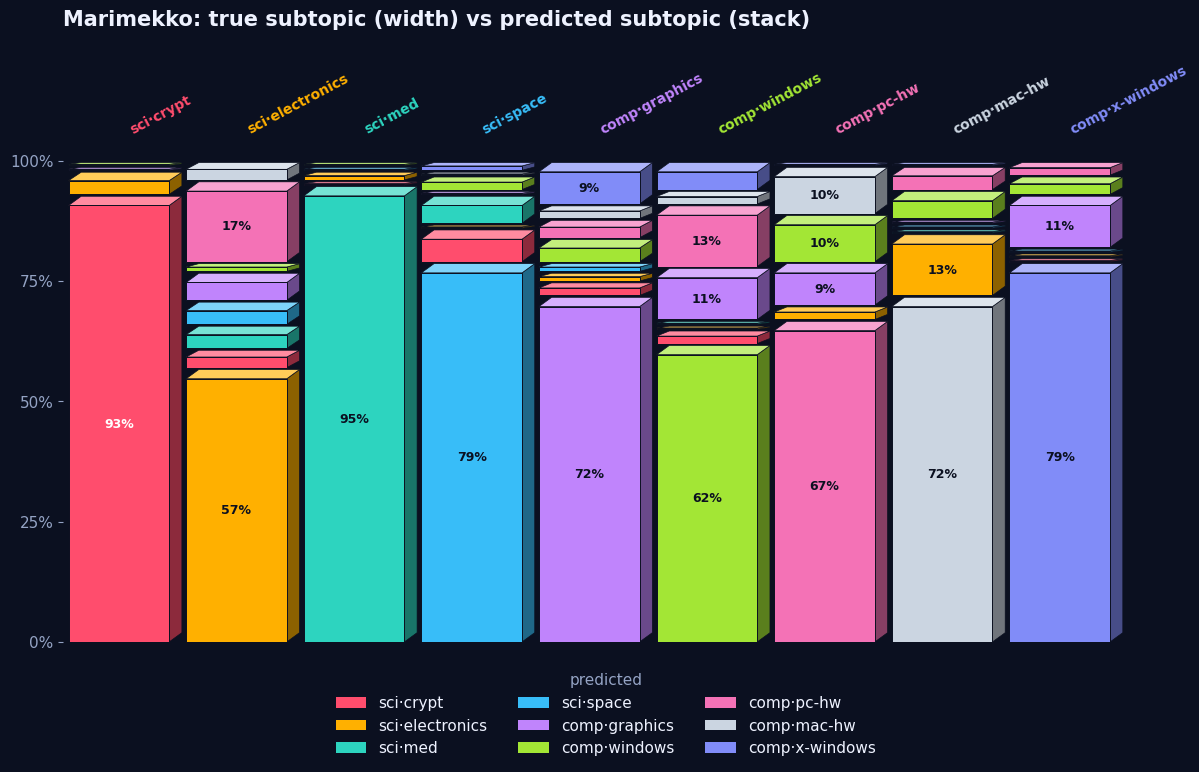

In [9]:
ct = (pd.crosstab(y_test, pred, normalize="index")
        .reindex(index=TOPICS, columns=TOPICS, fill_value=0))
counts = pd.Series(y_test).value_counts().reindex(TOPICS)
widths = counts / counts.sum()

fig, ax = plt.subplots(figsize=(14, 7.5))
x = 0.0
for t in TOPICS:
    w, y = widths[t], 0.0
    for p in [t] + [q for q in TOPICS if q != t]:
        h = ct.loc[t, p]
        if h <= 0:
            continue
        c = extruded_cell(ax, x, y, w, h, PAL[p])
        if c and h >= 0.08 and w >= 0.06:
            ax.text(*c, f"{h:.0%}", ha="center", va="center", fontsize=9, fontweight="bold", color=on_color(PAL[p]), zorder=10)
        y += h
    ax.text(x + w / 2, 1.05, short(t), rotation=28, ha="left", va="bottom", fontsize=10, color=PAL[t], fontweight="bold")
    x += w

ax.set_xlim(-0.005, 1.02); ax.set_ylim(0, 1.2)
ax.set_xticks([]); ax.set_yticks(np.linspace(0, 1, 5)); ax.set_yticklabels([f"{v:.0%}" for v in np.linspace(0, 1, 5)])
for s in ax.spines.values(): s.set_visible(False)
ax.set_title("Marimekko: true subtopic (width) vs predicted subtopic (stack)", loc="left", pad=28)
ax.legend(handles=[Patch(fc=PAL[t], label=short(t)) for t in TOPICS], title="predicted", ncol=3,
          loc="upper center", bbox_to_anchor=(0.5, -0.03), frameon=False, labelcolor=FG)
ax.get_legend().get_title().set_color(MUTED)
save_fig(fig, "1_marimekko"); plt.show()

saved figures/2_dendrogram.png


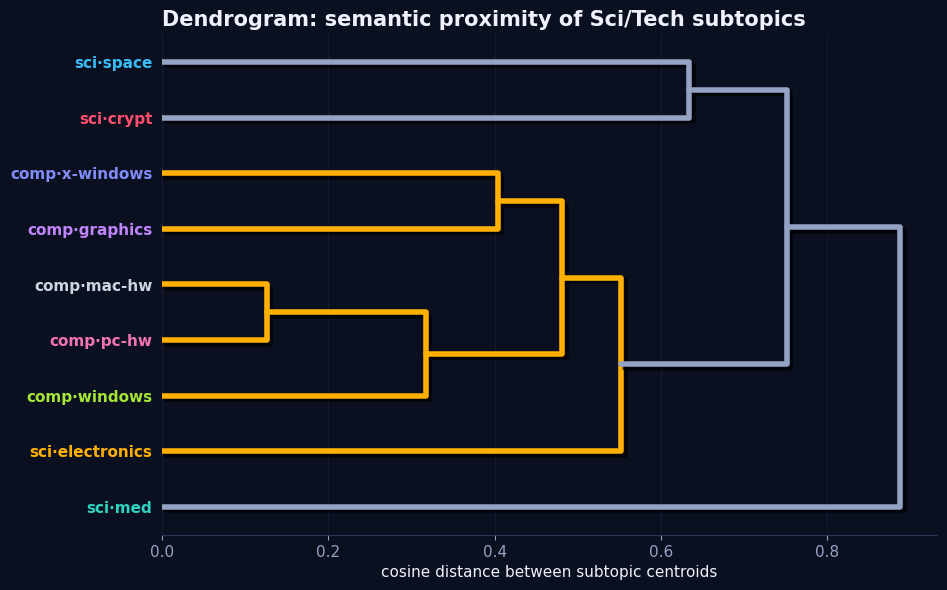

In [10]:
from scipy.cluster.hierarchy import linkage, dendrogram

cent = np.vstack([doc_emb[y_train == t].mean(0) for t in TOPICS])
cent /= np.linalg.norm(cent, axis=1, keepdims=True)
Z = linkage(cent, method="average", metric="cosine")

fig, ax = plt.subplots(figsize=(10, 6.5))
labels = [short(t) for t in TOPICS]
dendrogram(Z, labels=labels, orientation="right", ax=ax,
           color_threshold=0.65 * Z[-1, 2], above_threshold_color=MUTED)
for coll in ax.collections:
    coll.set_linewidth(4)
    coll.set_capstyle("round")
    coll.set_path_effects([pe.SimpleLineShadow(offset=(2.5, -2.5), shadow_color="black", alpha=0.65), pe.Normal()])
by_short = {short(t): PAL[t] for t in TOPICS}
for lbl in ax.get_yticklabels():
    lbl.set_color(by_short.get(lbl.get_text(), FG)); lbl.set_fontweight("bold"); lbl.set_fontsize(11)
ax.set_xlabel("cosine distance between subtopic centroids")
ax.grid(axis="x", alpha=0.35)
for s in ("top", "right", "left"): ax.spines[s].set_visible(False)
ax.set_title("Dendrogram: semantic proximity of Sci/Tech subtopics", loc="left")
save_fig(fig, "2_dendrogram"); plt.show()

saved figures/3_streamgraph.png


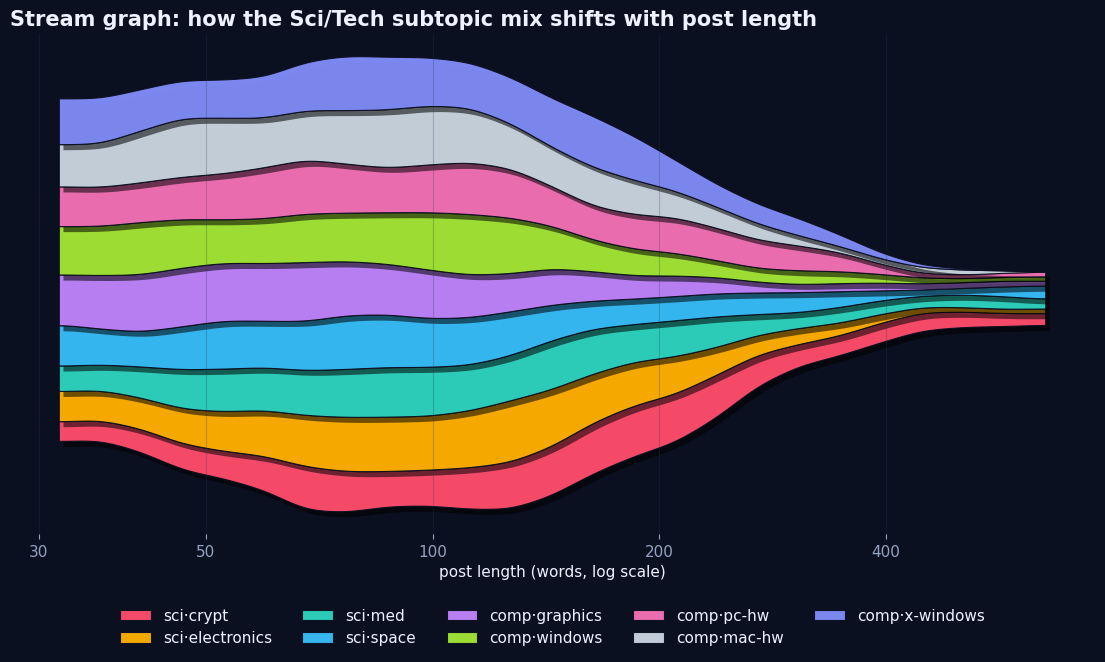

In [11]:
from scipy.ndimage import gaussian_filter1d

hi = np.percentile(train_df.n_words, 97)
edges = np.geomspace(MIN_WORDS, hi, 26)
centers = np.sqrt(edges[:-1] * edges[1:])
X = np.log10(centers)
Y = np.array([np.histogram(train_df.loc[train_df.label_text == t, "n_words"], bins=edges)[0] for t in TOPICS], float)
Y = gaussian_filter1d(Y, 1.0, axis=1)
xf = np.linspace(X.min(), X.max(), 500)
Yf = gaussian_filter1d(np.array([np.interp(xf, X, y) for y in Y]), 7, axis=1)

fig, ax = plt.subplots(figsize=(14, 6.5))
polys = ax.stackplot(xf, Yf, baseline="wiggle", colors=[PAL[t] for t in TOPICS],
                     labels=[short(t) for t in TOPICS], edgecolor=BG, linewidth=0.8, alpha=0.96)
for poly, t in zip(polys, TOPICS):
    poly.set_path_effects([pe.SimplePatchShadow(offset=(3, -4), shadow_rgbFace="black", alpha=0.55), pe.Normal()])
ticks = [v for v in (30, 50, 100, 200, 400, 800, 1600) if MIN_WORDS <= v <= hi]
ax.set_xticks(np.log10(ticks)); ax.set_xticklabels([str(v) for v in ticks])
ax.set_xlabel("post length (words, log scale)"); ax.set_yticks([])
for s in ax.spines.values(): s.set_visible(False)
ax.grid(axis="x", alpha=0.25)
ax.set_title("Stream graph: how the Sci/Tech subtopic mix shifts with post length", loc="left")
ax.legend(ncol=5, loc="upper center", bbox_to_anchor=(0.5, -0.12), frameon=False, labelcolor=FG)
save_fig(fig, "3_streamgraph"); plt.show()

saved figures/4_radial_bars.png


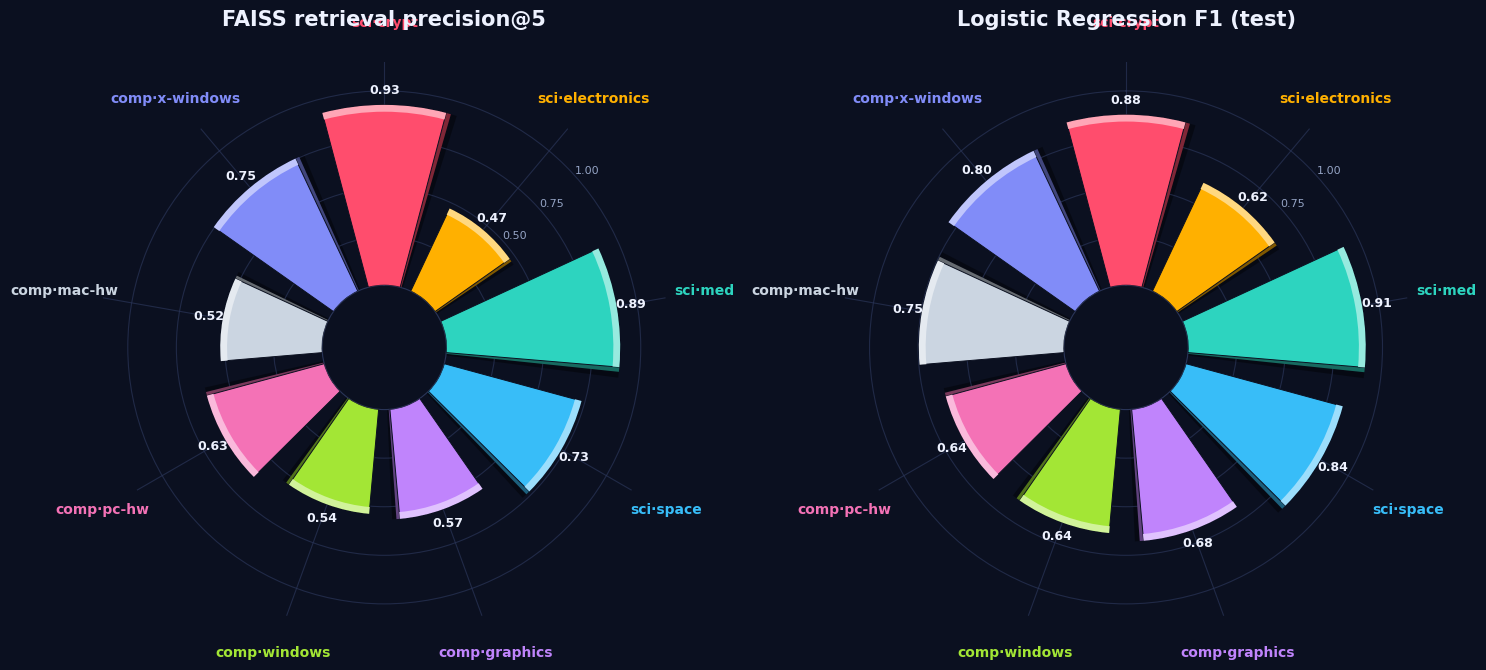

In [12]:
def radial_bars(ax, labels, values, colors, title):
    n = len(labels)
    theta = np.linspace(0, 2 * np.pi, n, endpoint=False)
    w = 2 * np.pi / n * 0.74
    ax.set_theta_offset(np.pi / 2); ax.set_theta_direction(-1)
    ax.set_rorigin(-0.32); ax.set_ylim(0, 1.15)
    for th, v, c in zip(theta, values, colors):
        v = float(v)
        ax.bar(th + 0.045, v, width=w, color="black", alpha=0.40, zorder=1)
        ax.bar(th + 0.020, v, width=w, color=shade(c, 0.50), zorder=2)
        ax.bar(th, v, width=w, color=c, edgecolor=BG, linewidth=0.7, zorder=3)
        ax.bar(th, 0.035, width=w, bottom=max(v - 0.035, 0), color=shade(c, 1.5), zorder=4)
        ax.text(th, min(v + 0.075, 1.11), f"{v:.2f}", ha="center", va="center", fontsize=9, fontweight="bold", color=FG, zorder=6)
    ax.set_xticks(theta); ax.set_xticklabels(labels, fontsize=10, fontweight="bold"); ax.tick_params(axis="x", pad=18)
    for lbl, c in zip(ax.get_xticklabels(), colors): lbl.set_color(c)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0]); ax.set_yticklabels(["0.25", "0.50", "0.75", "1.00"], fontsize=8, color=MUTED)
    ax.set_rlabel_position(180 / n * 2 + 8)
    ax.grid(color=GRID, alpha=0.7); ax.spines["polar"].set_visible(False)
    ax.set_title(title, pad=26)

fig = plt.figure(figsize=(15, 7.5))
cols = [PAL[t] for t in TOPICS]
radial_bars(fig.add_subplot(1, 2, 1, projection="polar"), [short(t) for t in TOPICS], prec_by_topic.values, cols,
            f"FAISS retrieval precision@{K_EVAL}")
radial_bars(fig.add_subplot(1, 2, 2, projection="polar"), [short(t) for t in TOPICS], f1_by_topic.values, cols,
            "Logistic Regression F1 (test)")
fig.tight_layout()
save_fig(fig, "4_radial_bars"); plt.show()

Explained variance (3 PCs): [0.047 0.033 0.029] | total 0.108
saved figures/5_pca_volume_3d.png


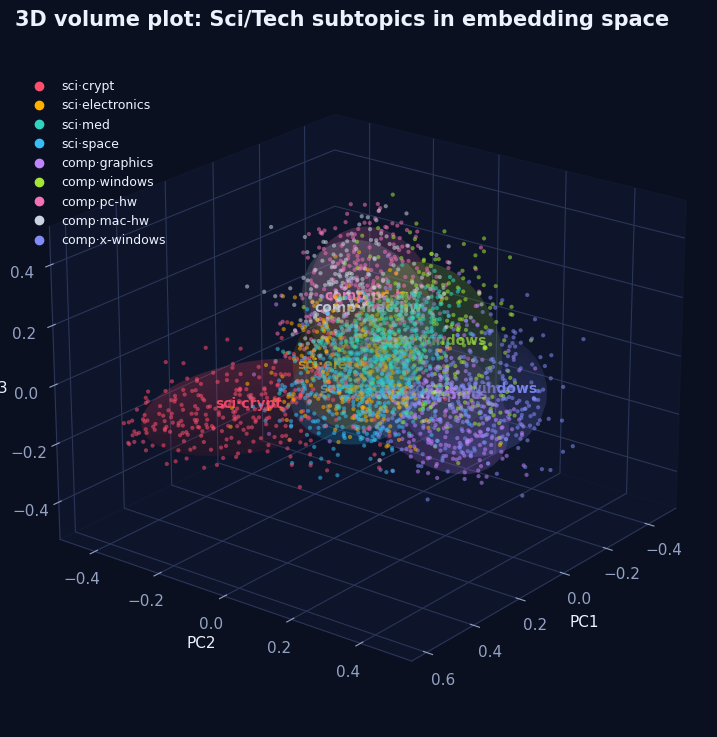

In [13]:
from mpl_toolkits.mplot3d import Axes3D

pca = PCA(n_components=3, random_state=SEED).fit(doc_emb)
P = pca.transform(doc_emb)
print("Explained variance (3 PCs):", np.round(pca.explained_variance_ratio_, 3), "| total", round(pca.explained_variance_ratio_.sum(), 3))

def ellipsoid(pts, k=1.6, n=32):
    mu, (w, V) = pts.mean(0), np.linalg.eigh(np.cov(pts.T))
    u, v = np.linspace(0, 2 * np.pi, n), np.linspace(0, np.pi, n)
    sph = np.stack([np.outer(np.cos(u), np.sin(v)), np.outer(np.sin(u), np.sin(v)),
                    np.outer(np.ones_like(u), np.cos(v))], axis=-1)
    e = sph @ (V * np.sqrt(np.clip(w, 0, None)) * k).T + mu
    return e[..., 0], e[..., 1], e[..., 2]

fig = plt.figure(figsize=(11, 9))
ax = fig.add_subplot(111, projection="3d")
for t in TOPICS:
    m = y_train == t
    ax.scatter(P[m, 0], P[m, 1], P[m, 2], s=9, color=PAL[t], alpha=0.55, depthshade=True, linewidths=0)
    ax.plot_surface(*ellipsoid(P[m]), color=PAL[t], alpha=0.13, linewidth=0, antialiased=True, shade=True)
    mu = P[m].mean(0)
    ax.text(*mu, short(t), color=PAL[t], fontsize=10, fontweight="bold", ha="center")
for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
    axis.set_pane_color((0.07, 0.10, 0.20, 0.55)); axis._axinfo["grid"]["color"] = GRID
ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.set_zlabel("PC3")
ax.view_init(elev=22, azim=38)
ax.set_title("3D volume plot: Sci/Tech subtopics in embedding space", loc="left")
ax.legend(handles=[Line2D([0], [0], marker="o", ls="", color=PAL[t], label=short(t)) for t in TOPICS],
          loc="upper left", bbox_to_anchor=(0.0, 0.95), frameon=False, labelcolor=FG, fontsize=9)
save_fig(fig, "5_pca_volume_3d"); plt.show()